# Lecture Two: Exploratory Data Analysis

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [3]:
dataset = pd.read_csv("/Users/mariamodubayo/Downloads/advancedProgramming_DataVisualisation/data/videogames.csv")

In [4]:
dataset.head(5)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


### Simple understanding of the dataset
    - Describe
    - Nulls
    - Duplicate 

In [5]:
dataset.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


## Data Visualisations

In [6]:
dataset['Genre'].value_counts()

Genre
Action          3316
Sports          2346
Misc            1739
Role-Playing    1488
Shooter         1310
Adventure       1286
Racing          1249
Platform         886
Simulation       867
Fighting         848
Strategy         681
Puzzle           582
Name: count, dtype: int64

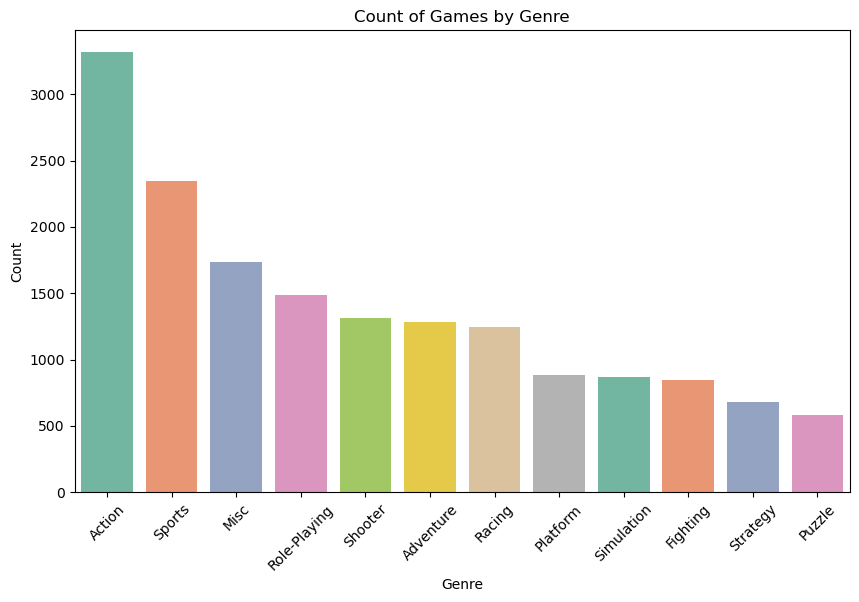

In [7]:
# Visualize the count of games by genre
plt.figure(figsize=(10, 6))
sns.countplot(data=dataset,
               x='Genre',
               palette='Set2',
               order=dataset['Genre'].value_counts().index)
plt.title('Count of Games by Genre')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

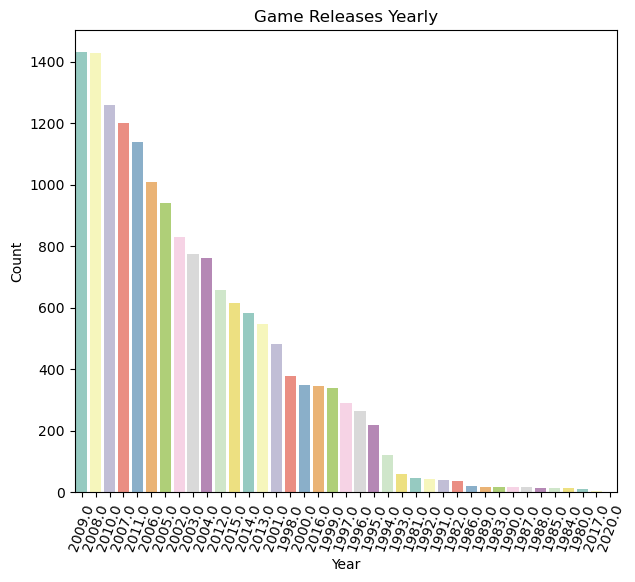

In [8]:
#Which year ahd the most game release 
plt.figure(figsize=(7, 6))
sns.countplot(data=dataset,
              x='Year',
              palette='Set3',
              order=dataset['Year'].value_counts().index )
plt.title("Game Releases Yearly")
plt.xlabel("Year")
plt.ylabel("Count")
plt.xticks(rotation=70)
plt.show()


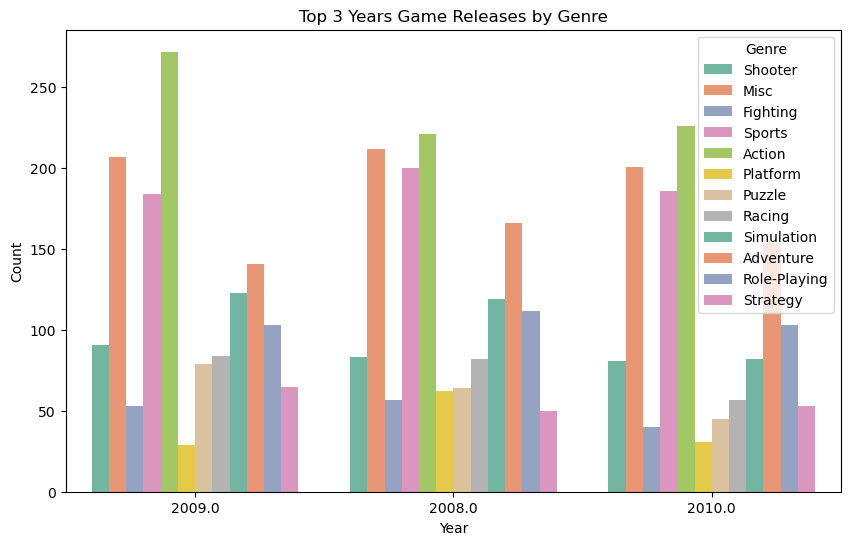

In [9]:
#Top 3 years game releases by Genre

plt.figure(figsize=(10, 6))
sns.countplot(data=dataset,
              x='Year',
              hue='Genre',
              palette='Set2',
              order=dataset.Year.value_counts().iloc[:3].index) #.iloc[:3] to get the top 3 years with the most game releases
plt.title("Top 3 Years Game Releases by Genre")
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend(title='Genre')
plt.show()

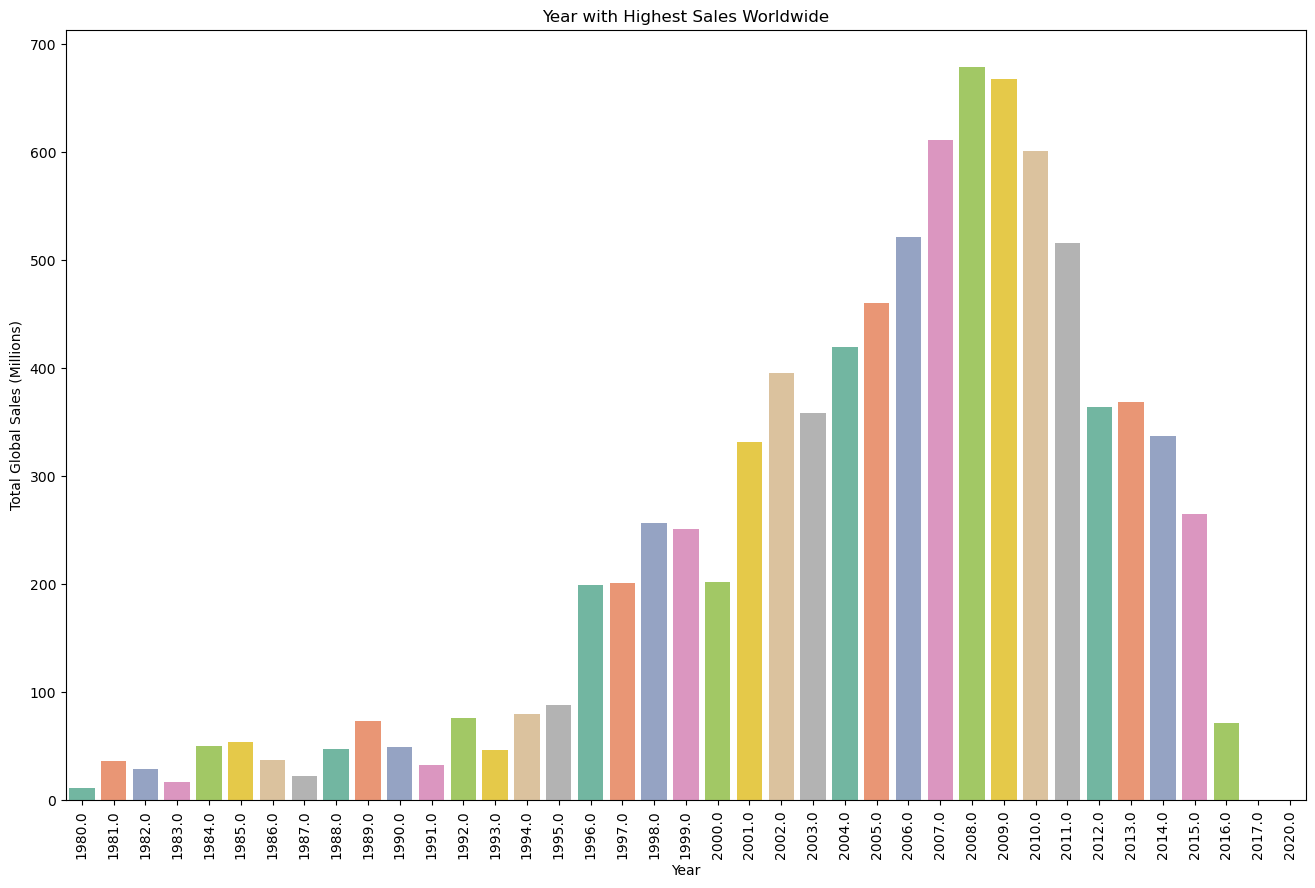

In [10]:
#Year with highest sales worldwide in descending order 
videogame_year = dataset.groupby('Year')['Global_Sales'].sum()
videogame_year = videogame_year.reset_index()
videogame_year.sort_values(by=['Global_Sales'], ascending= False)

plt.figure(figsize=(16, 10))
sns.barplot(data=videogame_year,
            x = 'Year',
            y = 'Global_Sales',
            palette='Set2',
            )
plt.title("Year with Highest Sales Worldwide")
plt.xlabel("Year")
plt.xticks(rotation=90)
plt.ylabel("Total Global Sales (Millions)")
plt.show()

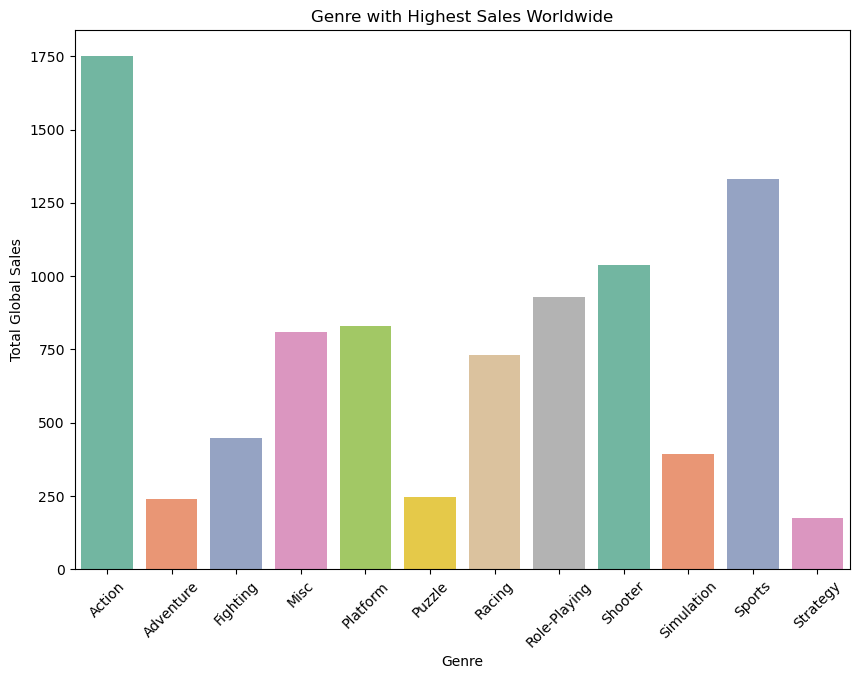

In [11]:
#Which genre had the highest sales worldwide in descending order
videogame_genre = dataset.groupby('Genre')['Global_Sales'].sum()
videogame_genre = videogame_genre.reset_index()
videogame_genre.sort_values(by=['Global_Sales'], ascending= False)

plt.figure(figsize=(10, 7))
sns.barplot(data=videogame_genre,
            x = 'Genre',
            y = 'Global_Sales',
            palette='Set2',
            )
            
plt.title("Genre with Highest Sales Worldwide")
plt.xlabel("Genre")
plt.xticks(rotation=45)
plt.ylabel("Total Global Sales")
plt.show()

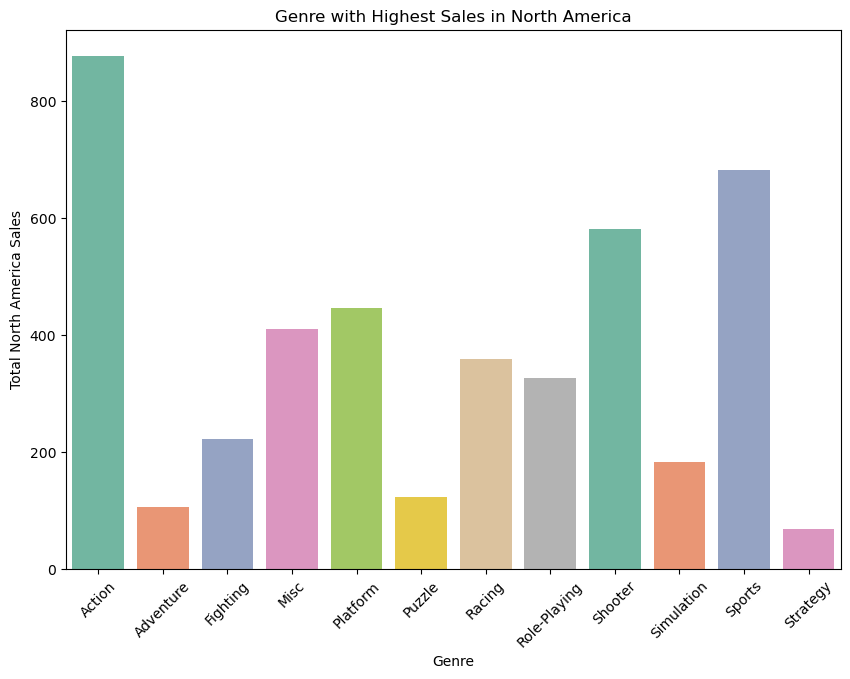

In [12]:
#Which genre had the highest sales in America in descending order
videogame_genre = dataset.groupby('Genre')['NA_Sales'].sum()
videogame_genre = videogame_genre.reset_index()
videogame_genre.sort_values(by=['NA_Sales'], ascending= False)

plt.figure(figsize=(10, 7))
sns.barplot(
            x = 'Genre',
            y = 'NA_Sales',
            data=videogame_genre,
            palette='Set2',
            )
            
plt.title("Genre with Highest Sales in North America")
plt.xlabel("Genre")
plt.xticks(rotation=45)
plt.ylabel("Total North America Sales")
plt.show()

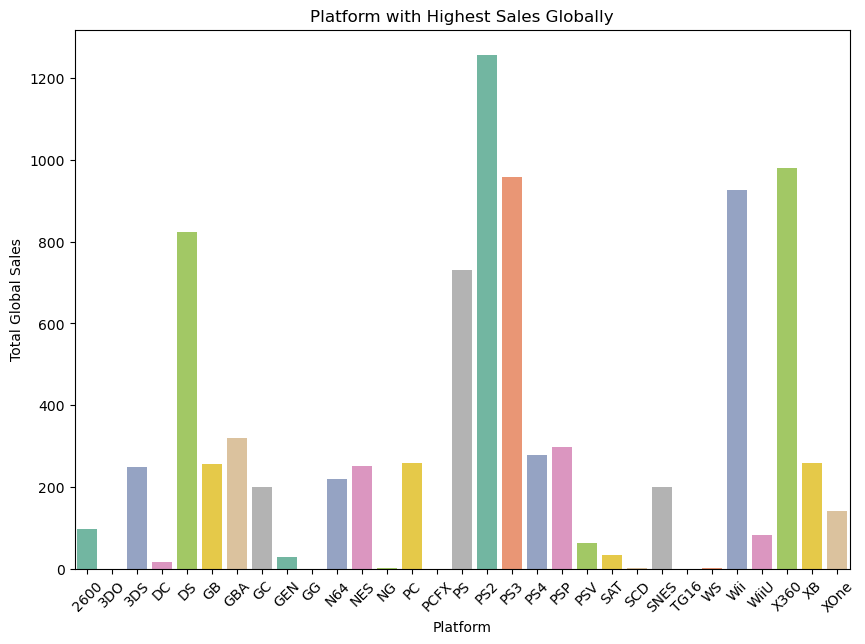

In [13]:
#Which Platform had the highest sales Globally in descending order
videogame_platform = dataset.groupby('Platform')['Global_Sales'].sum()
videogame_platform = videogame_platform.reset_index()
videogame_platform.sort_values(by=['Global_Sales'], ascending= False)

plt.figure(figsize=(10, 7))
sns.barplot(
            x = 'Platform',
            y = 'Global_Sales',
            data=videogame_platform,
            palette='Set2',
            )
            
plt.title("Platform with Highest Sales Globally")
plt.xlabel("Platform")
plt.xticks(rotation=45)
plt.ylabel("Total Global Sales")
plt.show()

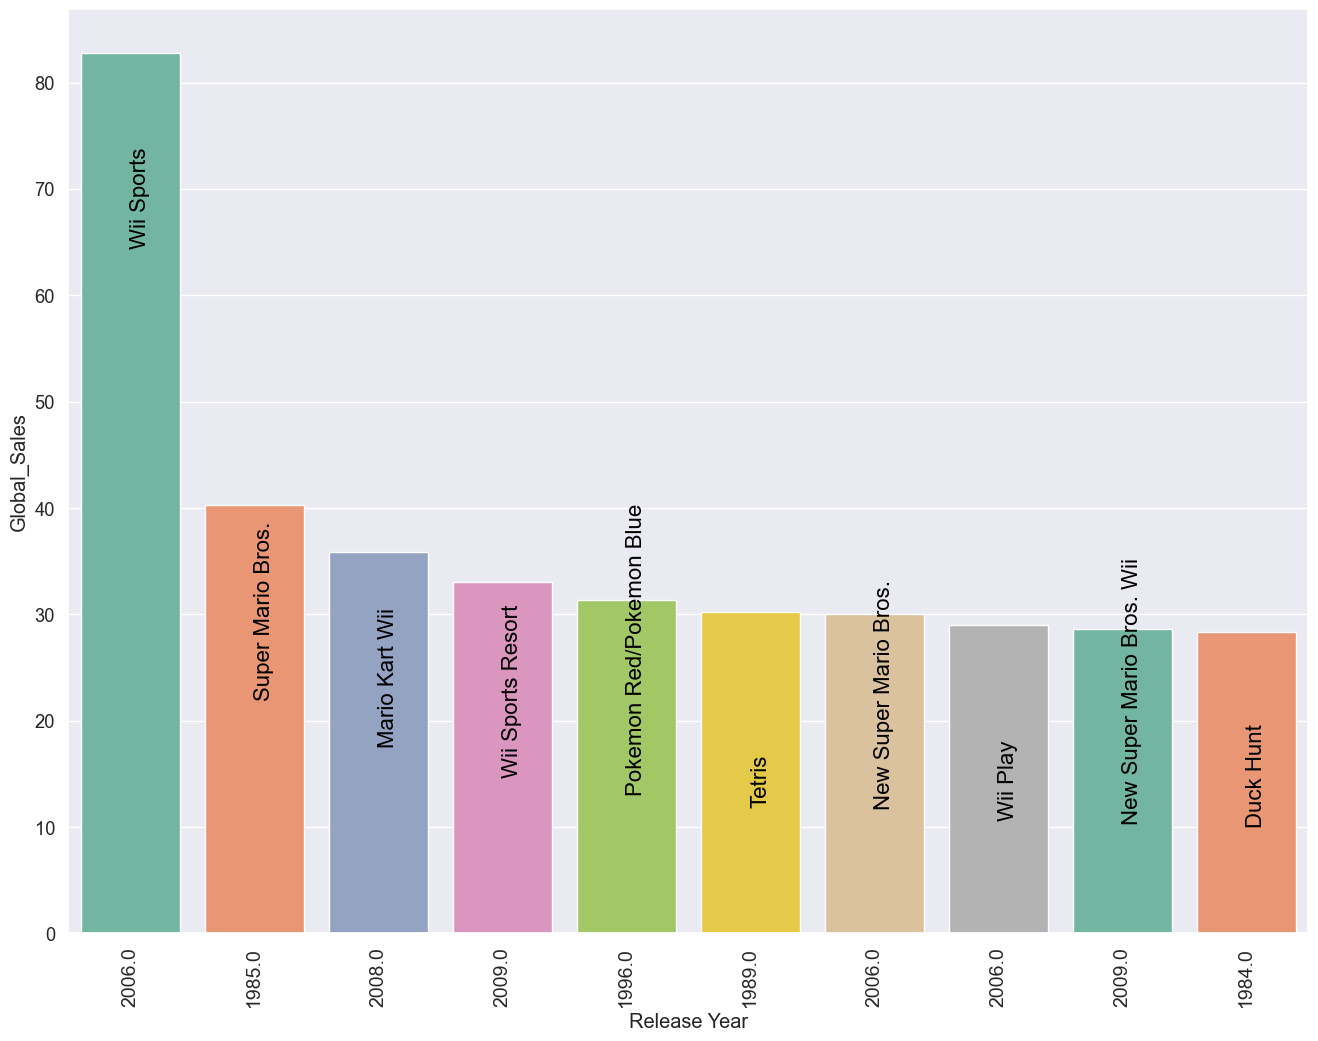

In [27]:
#Which individual game had the highest sales in globally

topVideoGame = dataset.head(10)
topVideoGame = topVideoGame[['Name', 'Year', 'Genre', 'Global_Sales']]
topVideoGame = topVideoGame.sort_values(by=['Global_Sales'], ascending=False)
name = topVideoGame['Name']
year = topVideoGame['Year']
y = np.arange(0,10)
plt.figure(figsize = (16, 12))
g = sns.barplot(x = 'Name', y = 'Global_Sales', data = topVideoGame, palette='Set2')
index = 0
for value in topVideoGame['Global_Sales']:
    g.text(index, value - 18, name[index], color = '#000', size = 16, rotation = 90)
    index += 1
plt.xticks(y, topVideoGame['Year'], fontsize = 14, rotation = 90)
plt.xlabel('Release Year')
plt.show()


## Correlation/ Heat Map

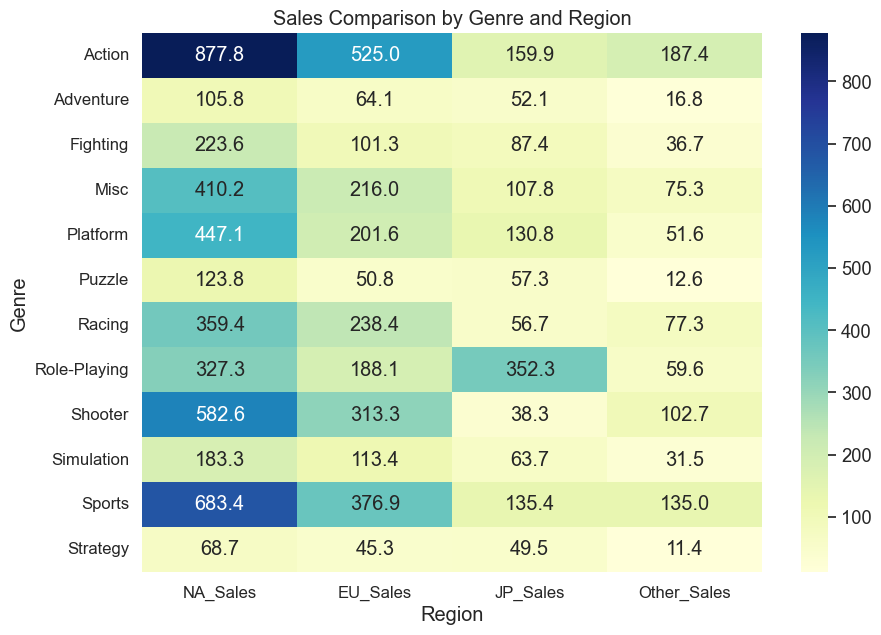

In [15]:
comp_genre = dataset[['Genre','NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']]
comp_map = comp_genre.groupby('Genre').sum()

plt.figure(figsize=(10, 7))
sns.set(font_scale=1.2)
sns.heatmap(comp_map, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Sales Comparison by Genre and Region")
plt.xlabel("Region")
plt.ylabel("Genre")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [16]:
#Making Genre become a column instead of an index 
comp_table = comp_map.reset_index()
#Reshape the DataFrame from wide to long format for better visualization
comp_table = pd.melt(comp_table, id_vars='Genre', value_vars=['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales'],
                      var_name='Sale_Area', value_name='Sale_Price')
comp_table.head(5)

,Genre,Sale_Area,Sale_Price
0,Action,NA_Sales,877.83
1,Adventure,NA_Sales,105.80
2,Fighting,NA_Sales,223.59
3,Misc,NA_Sales,410.24
4,Platform,NA_Sales,447.05


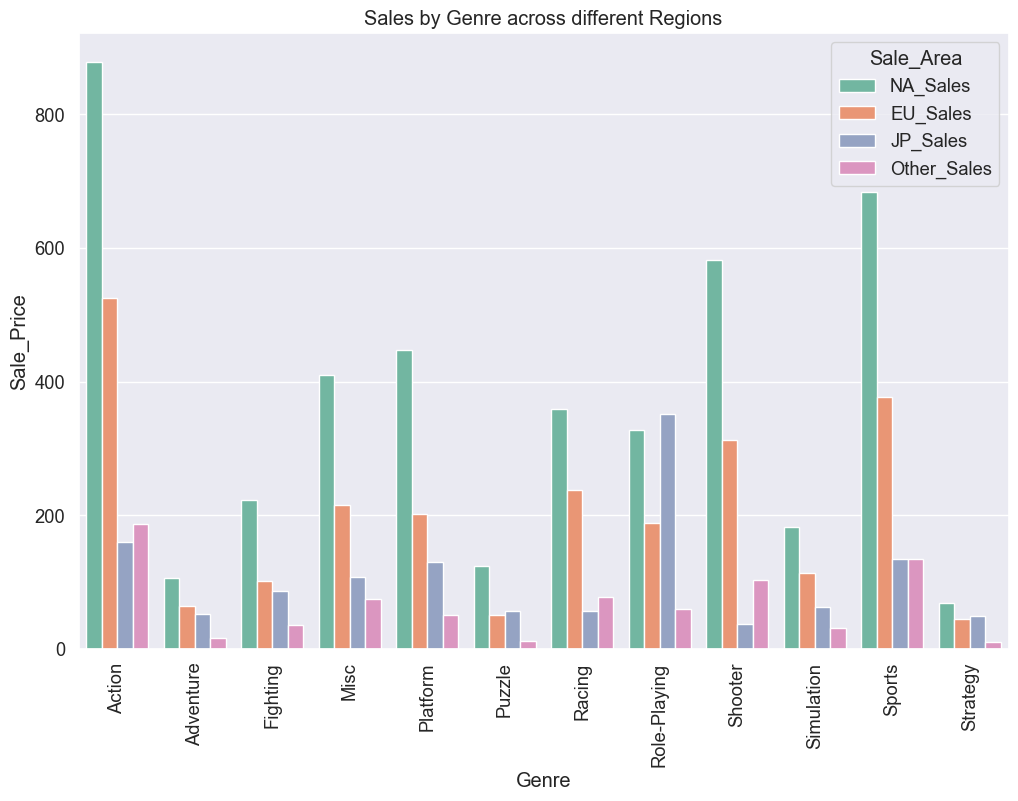

In [17]:
plt.figure(figsize=(12, 8))
sns.barplot(data=comp_table,
            x='Genre',
            y='Sale_Price',
            hue='Sale_Area',
            palette='Set2',
)
plt.title('Sales by Genre across different Regions')
plt.xticks(rotation=90)
plt.show()

### Top Publishers

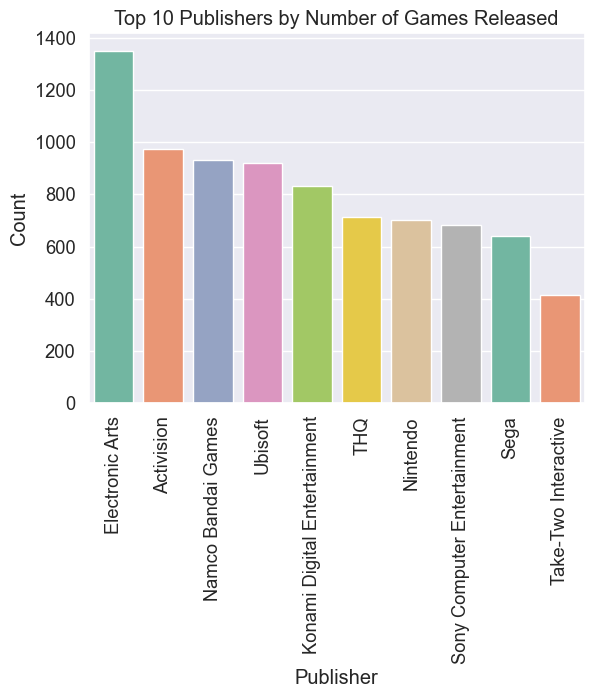

In [18]:
top_publisher = dataset.groupby('Publisher')['Year'].count().sort_values(ascending=False).head(10)
top_publisher = pd.DataFrame(top_publisher).reset_index()

sns.countplot(data=dataset,
                x='Publisher',
                palette='Set2',
                order=dataset['Publisher'].value_counts().head(10).index)
plt.title('Top 10 Publishers by Number of Games Released')
plt.xlabel('Publisher')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

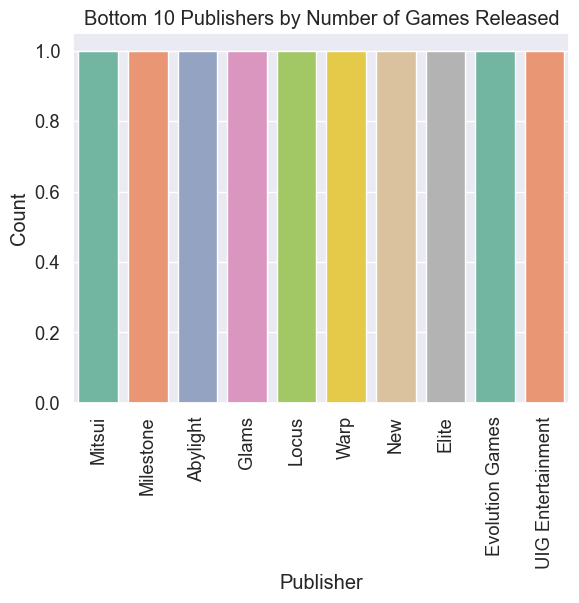

In [19]:
bottom_publisher = dataset.groupby('Publisher')['Year'].count().sort_values(ascending=False).tail(10)
bottom_publisher = pd.DataFrame(bottom_publisher).reset_index()

sns.countplot(data=dataset,
                x='Publisher',
                palette='Set2',
                order=dataset['Publisher'].value_counts().tail(10).index)
plt.title('Bottom 10 Publishers by Number of Games Released')
plt.xlabel('Publisher')
plt.ylabel('Count')
plt.xticks(rotation=90);

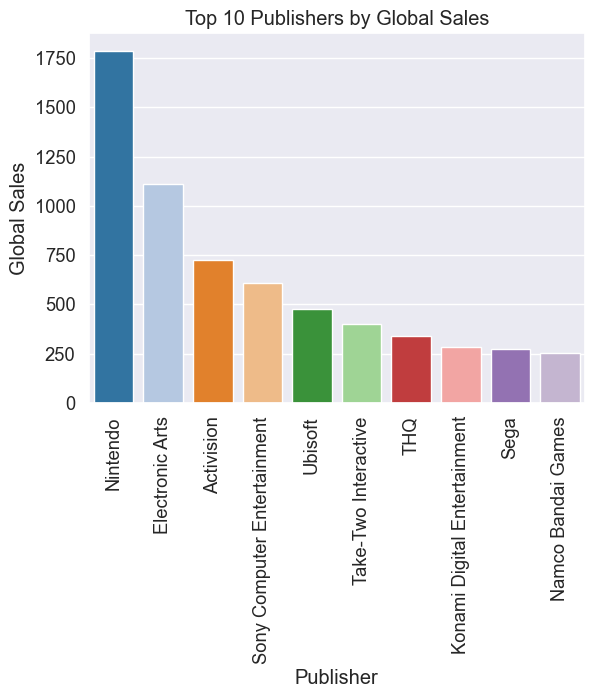

In [20]:
sales_by_publisher = dataset[['Publisher','Global_Sales']]
sales_by_publisher = sales_by_publisher.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(10)
sales_by_publisher = pd.DataFrame(sales_by_publisher).reset_index()

sns.barplot(data=sales_by_publisher,
                x='Publisher',
                y='Global_Sales',
                palette='tab20',
                )
plt.title('Top 10 Publishers by Global Sales')
plt.xlabel('Publisher')
plt.ylabel('Global Sales')
plt.xticks(rotation=90)
plt.show()

In [21]:
comp_publisher = dataset[['Publisher','NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']]
comp_publisher.head(20)

,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,Nintendo,41.49,29.02,3.77,8.46,82.74
1,Nintendo,29.08,3.58,6.81,0.77,40.24
2,Nintendo,15.85,12.88,3.79,3.31,35.82
3,Nintendo,15.75,11.01,3.28,2.96,33.00
4,Nintendo,11.27,8.89,10.22,1.00,31.37
5,Nintendo,23.20,2.26,4.22,0.58,30.26
6,Nintendo,11.38,9.23,6.50,2.90,30.01
7,Nintendo,14.03,9.20,2.93,2.85,29.02
8,Nintendo,14.59,7.06,4.70,2.26,28.62
9,Nintendo,26.93,0.63,0.28,0.47,28.31


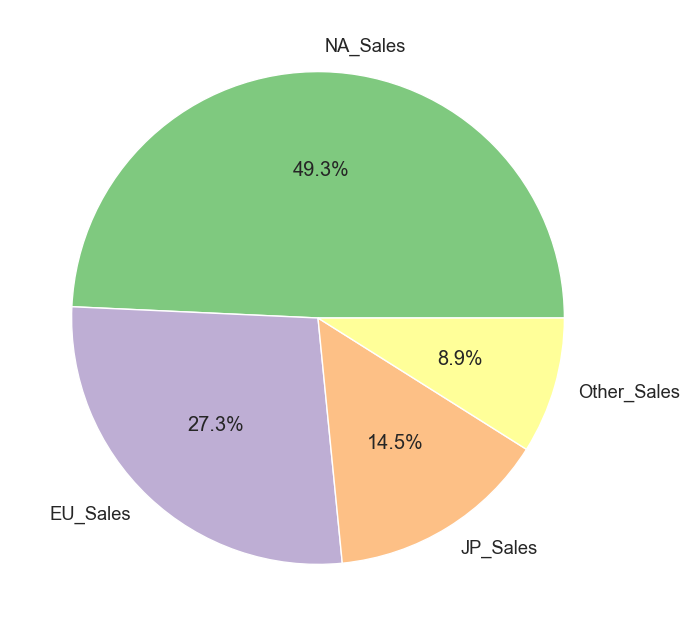

In [22]:
topSalesRegion = dataset[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']]
topSalesRegion = topSalesRegion.sum().reset_index()
topSalesRegion = topSalesRegion.rename(columns={'index': 'Region', 0: 'Sales'})

labels = topSalesRegion['Region']
sizes = topSalesRegion['Sales']

plt.figure(figsize=(8, 8))
colors = sns.color_palette('Accent', len(labels))
plt.pie(sizes,
        labels=labels,
        autopct='%1.1f%%',
        colors=colors)
plt.show()

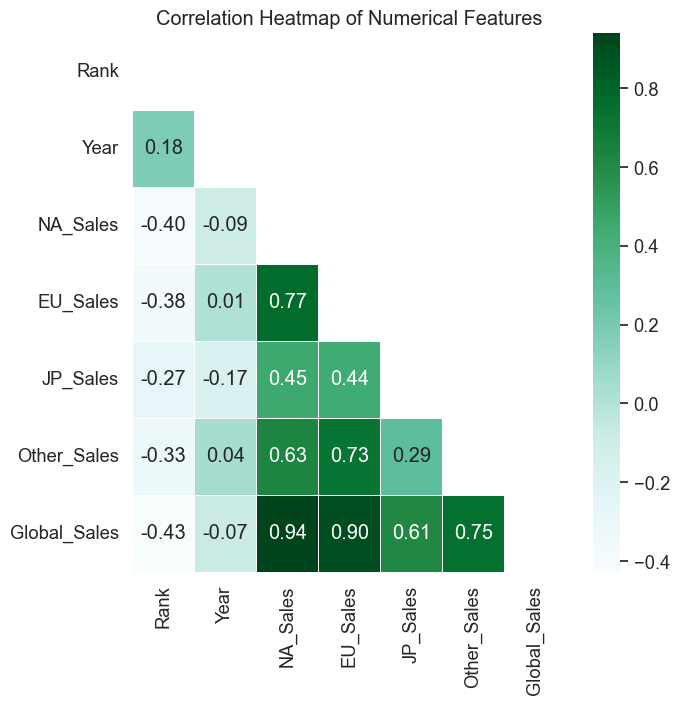

In [23]:
corr = dataset.select_dtypes(include=np.number).corr() #Select only numerical columns and compute the correlation matrix

plt.figure(figsize=(7, 7))

mask = np.zeros_like(corr) #Create a mask of zeros with the same shape as the correlation matrix
mask[np.triu_indices_from(mask)] = True #Set the upper triangle of the mask to True, which will hide those values in the heatmap

with sns.axes_style("white"):
    ax = sns.heatmap(corr, mask=mask, cmap='BuGn', annot=True, fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


In [24]:
pair_data = dataset.loc[:,['Year','Platform','Genre', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']]
pair_data.head(5)


,Year,Platform,Genre,NA_Sales,EU_Sales,JP_Sales,Other_Sales
0,2006.0,Wii,Sports,41.49,29.02,3.77,8.46
1,1985.0,NES,Platform,29.08,3.58,6.81,0.77
2,2008.0,Wii,Racing,15.85,12.88,3.79,3.31
3,2009.0,Wii,Sports,15.75,11.01,3.28,2.96
4,1996.0,GB,Role-Playing,11.27,8.89,10.22,1.00


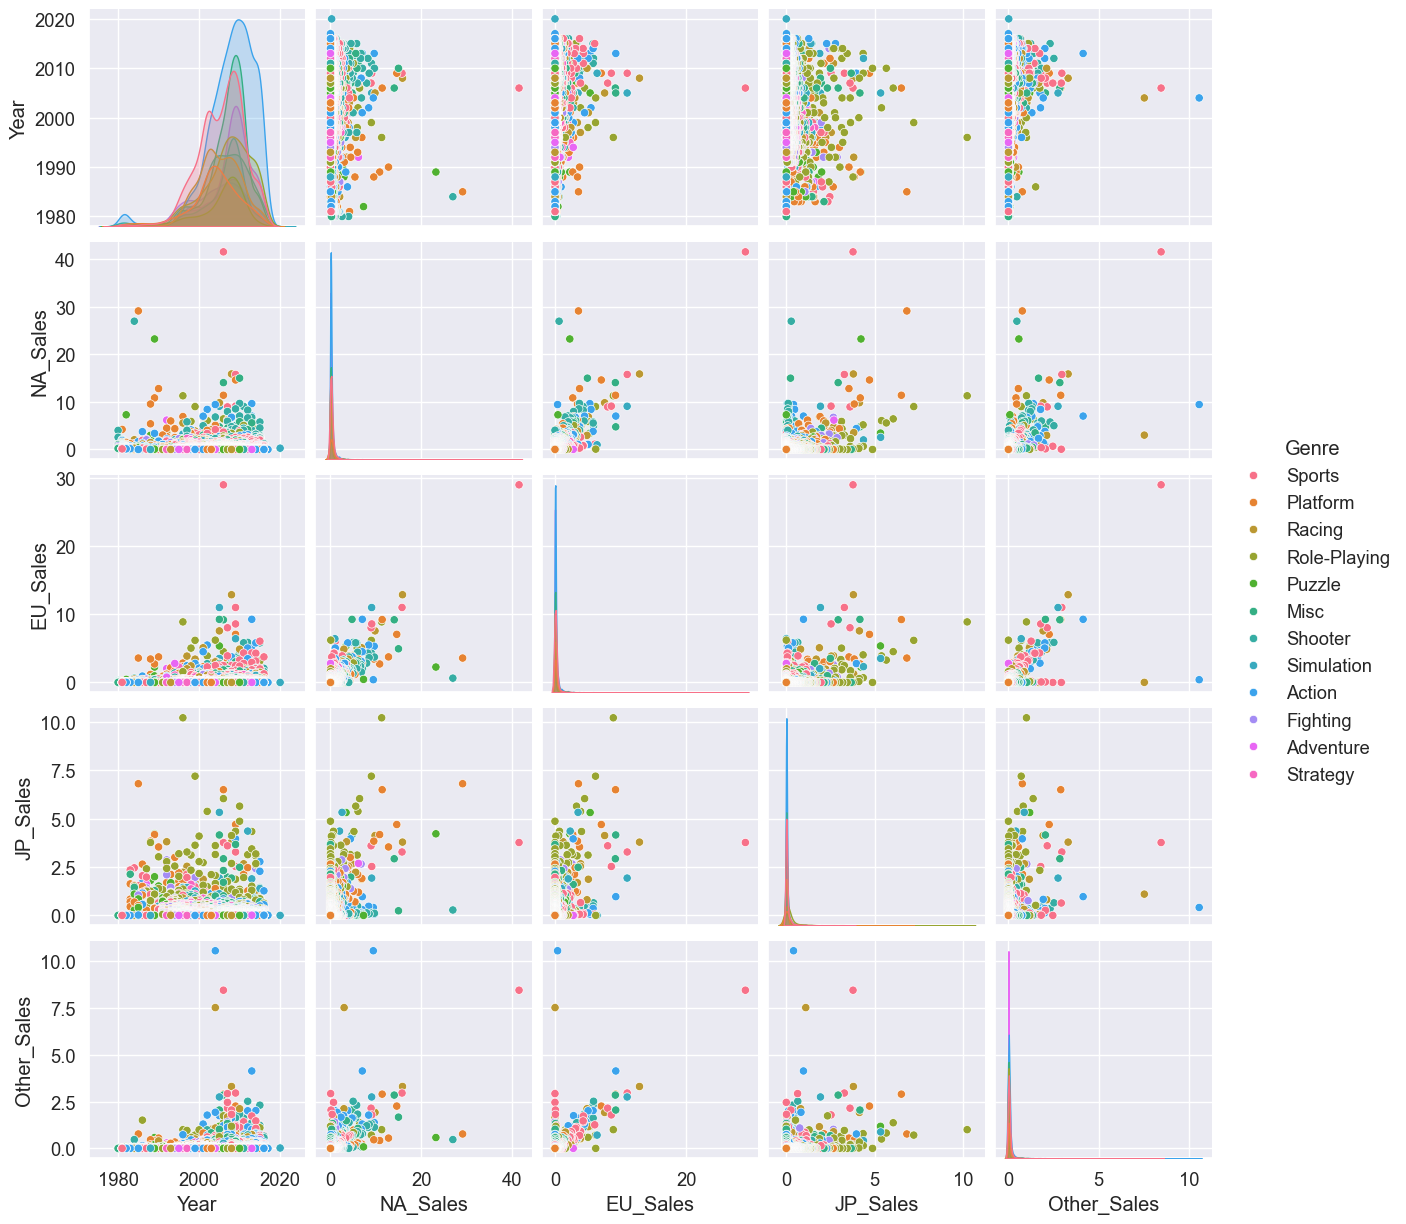

In [26]:
#Pairplot to visualize the relationships between numerical features, colored by Global_Sales
sns.pairplot(pair_data, hue='Genre')

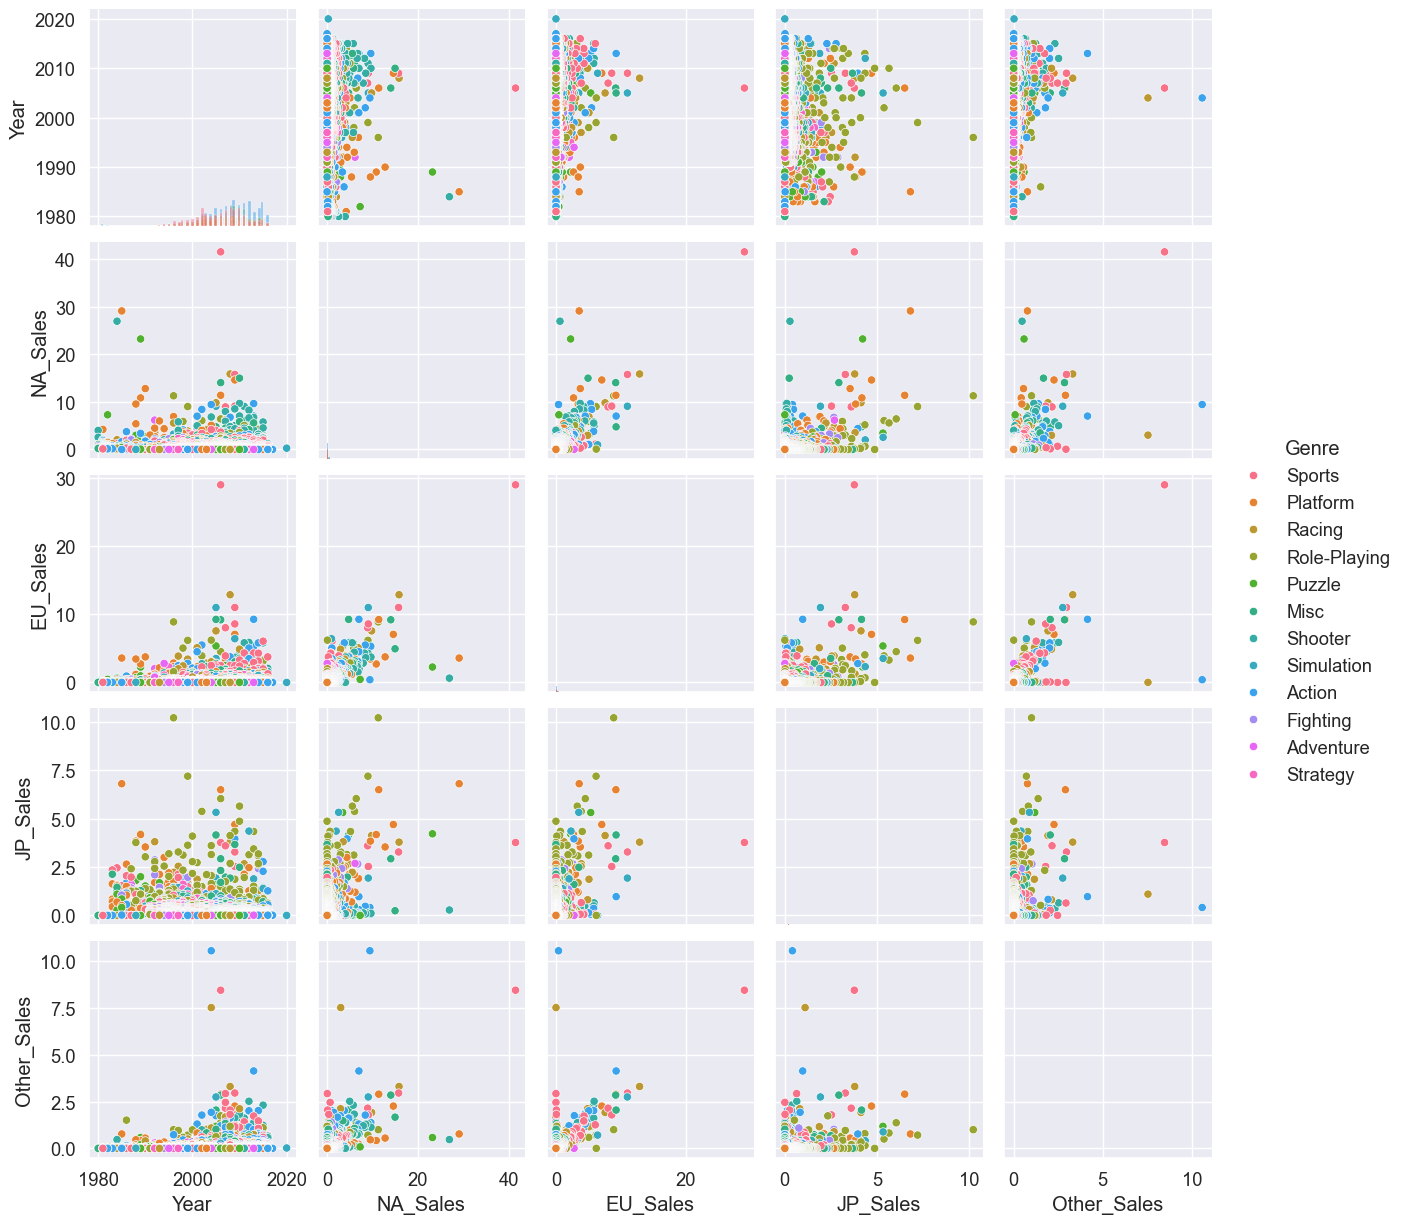

In [28]:
#Pairplot to visualize the relationships between numerical features, colored by Global_Sales with histogram on the diagonal
sns.pairplot(pair_data,
              hue='Genre',
              diag_kind='hist'
              )